<a href="https://colab.research.google.com/github/omjaiswal2004/First_project_todolist/blob/main/resDatapreprocesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import zipfile
import shutil
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/chest_xray'
DATA_PATH = '/content/drive/MyDrive/chest_xray'
PROCESSED_DATA_PATH = '/content/processed_data'

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
os.makedirs(f"{PROCESSED_DATA_PATH}/train", exist_ok=True)
os.makedirs(f"{PROCESSED_DATA_PATH}/val", exist_ok=True)
os.makedirs(f"{PROCESSED_DATA_PATH}/test", exist_ok=True)


In [ ]:
def verify_data_structure():
    """Quick verification of your Google Drive data structure"""
    print("🔍 Verifying Google Drive data structure...")

    try:
        drive.mount('/content/drive')
        print("✓ Google Drive mounted successfully")
    except:
        print("❌ Failed to mount Google Drive")
        return

    # Check main folder
    main_path = '/content/drive/MyDrive/chest_xray'
    if os.path.exists(main_path):
        print(f"✓ Found main directory: {main_path}")

        # List contents
        contents = os.listdir(main_path)
        print(f"📁 Contents: {contents}")

        # Check each subfolder
        for split in ['train', 'test', 'val']:
            split_path = os.path.join(main_path, split)
            if os.path.exists(split_path):
                classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
                print(f"✓ {split}/ contains classes: {classes}")

                # Count images in each class
                for class_name in classes:
                    class_path = os.path.join(split_path, class_name)
                    image_count = len([f for f in os.listdir(class_path)
                                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    print(f"  📊 {class_name}: {image_count} images")
            else:
                print(f"❌ {split}/ folder not found")
    else:
        print(f"❌ Main directory not found: {main_path}")
        print("Please check if your folder is named 'chest_xray' and is in your Google Drive root")



In [ ]:
# Quick setup function for your specific case
def quick_setup():
    """Quick setup function tailored to your Google Drive structure"""
    print("🚀 Quick Setup for Q-Health Scan Project")
    print("=" * 50)

    # Mount and verify
    verify_data_structure()

    print("\n📋 Next steps:")
    print("1. If verification passed, run: run_preprocessing_pipeline()")
    print("2. If there are issues, check your folder names and structure")
    print("3. Make sure your data folders contain 'NORMAL' and 'PNEUMONIA' subfolders")

# Call this first to verify everything is set up correctly
quick_setup()


🚀 Quick Setup for Q-Health Scan Project
🔍 Verifying Google Drive data structure...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully
✓ Found main directory: /content/drive/MyDrive/chest_xray
📁 Contents: ['.DS_Store', 'test', 'val', 'train']
✓ train/ contains classes: ['PNEUMONIA', 'NORMAL']
  📊 PNEUMONIA: 3891 images
  📊 NORMAL: 1355 images
✓ test/ contains classes: ['NORMAL', 'PNEUMONIA']
  📊 NORMAL: 234 images
  📊 PNEUMONIA: 390 images
✓ val/ contains classes: ['PNEUMONIA', 'NORMAL']
  📊 PNEUMONIA: 8 images
  📊 NORMAL: 8 images

📋 Next steps:
1. If verification passed, run: run_preprocessing_pipeline()
2. If there are issues, check your folder names and structure
3. Make sure your data folders contain 'NORMAL' and 'PNEUMONIA' subfolders


In [ ]:
def check_data_structure():
    """Check if data structure is correct"""
    print("Step 1: Checking data structure...")

    if not os.path.exists(DATA_PATH):
        print(f"❌ Data path not found: {DATA_PATH}")
        print("Please check your Google Drive path and mount status")
        return None

    print(f"✓ Found data directory: {DATA_PATH}")

    required_folders = ['train', 'test', 'val']
    for folder in required_folders:
        folder_path = os.path.join(DATA_PATH, folder)
        if os.path.exists(folder_path):
            print(f"✓ Found {folder} folder")
        else:
            print(f"❌ Missing {folder} folder")
            return None

    return DATA_PATH



In [ ]:
def analyze_dataset_structure(data_path):
    """Analyze the dataset structure and class distribution"""
    print("\nStep 2: Analyzing dataset structure...")

    dataset_info = {}

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(data_path, split)
        if os.path.exists(split_path):
            classes = os.listdir(split_path)
            dataset_info[split] = {}

            for class_name in classes:
                class_path = os.path.join(split_path, class_name)
                if os.path.isdir(class_path):
                    count = len([f for f in os.listdir(class_path)
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    dataset_info[split][class_name] = count

    print("\n📊 Dataset Structure:")
    for split, classes in dataset_info.items():
        print(f"\n{split.upper()} SET:")
        total = sum(classes.values())
        for class_name, count in classes.items():
            percentage = (count/total)*100 if total > 0 else 0
            print(f"  {class_name}: {count} images ({percentage:.1f}%)")
        print(f"  Total: {total} images")

    return dataset_info

In [ ]:
def load_and_preprocess_image(image_path, target_size=(224, 224), normalize=True):
    """Load and preprocess a single image"""
    try:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            return None

        # Resize image
        image = cv2.resize(image, target_size)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        image = clahe.apply(image)

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        # Normalize pixel values
        if normalize:
            image = image.astype(np.float32) / 255.0

        return image

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [ ]:
def analyze_image_properties(data_path, sample_size=100):
    """Analyze image properties to determine optimal preprocessing parameters"""
    print(f"\nStep 3: Analyzing image properties (sampling {sample_size} images)...")

    image_info = {
        'sizes': [],
        'mean_intensities': [],
        'std_intensities': []
    }

    sample_count = 0

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(data_path, split)
        if not os.path.exists(split_path):
            continue

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            for img_file in os.listdir(class_path)[:sample_size//6]:
                if sample_count >= sample_size:
                    break

                img_path = os.path.join(class_path, img_file)
                if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        image_info['sizes'].append(img.shape)
                        image_info['mean_intensities'].append(np.mean(img))
                        image_info['std_intensities'].append(np.std(img))
                        sample_count += 1

                except Exception as e:
                    continue

    # Analyze results
    sizes = image_info['sizes']
    if sizes:
        heights = [s[0] for s in sizes]
        widths = [s[1] for s in sizes]

        print(f"✓ Analyzed {len(sizes)} images")
        print(f"Height range: {min(heights)} - {max(heights)} (avg: {np.mean(heights):.0f})")
        print(f"Width range: {min(widths)} - {max(widths)} (avg: {np.mean(widths):.0f})")
        print(f"Mean intensity: {np.mean(image_info['mean_intensities']):.2f} ± {np.std(image_info['mean_intensities']):.2f}")

    return image_info


In [ ]:
# Step 4: Create balanced dataset
def create_balanced_dataset(data_path, target_size=(224, 224), balance_classes=True):
    """Create a balanced and preprocessed dataset"""
    print(f"\nStep 4: Creating balanced dataset...")

    all_images = []
    all_labels = []

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(data_path, split)
        if not os.path.exists(split_path):
            continue

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    all_images.append(img_path)
                    all_labels.append(class_name)

    print(f"✓ Found {len(all_images)} total images")

    # Create label encoder
    le = LabelEncoder()
    encoded_labels = le.fit_transform(all_labels)

    # Balance classes if requested
    if balance_classes:
        label_counts = Counter(all_labels)
        min_count = min(label_counts.values())
        print(f"✓ Balancing classes to {min_count} samples each")

        balanced_images = []
        balanced_labels = []

        for class_name in le.classes_:
            class_indices = [i for i, label in enumerate(all_labels) if label == class_name]
            np.random.shuffle(class_indices)
            selected_indices = class_indices[:min_count]

            for idx in selected_indices:
                balanced_images.append(all_images[idx])
                balanced_labels.append(all_labels[idx])

        all_images = balanced_images
        all_labels = balanced_labels
        encoded_labels = le.transform(all_labels)

    print(f"✓ Final dataset size: {len(all_images)} images")
    print(f"✓ Class distribution: {Counter(all_labels)}")

    return all_images, all_labels, encoded_labels, le


In [ ]:
# Step 5: Data augmentation setup
def setup_data_augmentation():
    """Setup data augmentation for training"""
    print("\nStep 5: Setting up data augmentation...")

    # Training data augmentation
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='nearest',
        rescale=1./255
    )

    # Validation/test data (no augmentation, only rescaling)
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    print("✓ Data augmentation configured")
    return train_datagen, val_test_datagen

In [ ]:
def quantum_preprocessing(images, quantum_feature_map='amplitude'):
    """
    Preprocess images for quantum machine learning
    """
    print(f"\nStep 6: Quantum preprocessing with {quantum_feature_map} encoding...")

    processed_images = []

    for img in images:
        # Ensure image is normalized
        if img.max() > 1.0:
            img = img.astype(np.float32) / 255.0

        if quantum_feature_map == 'amplitude':
            # Amplitude encoding: flatten and normalize
            flattened = img.flatten()
            # Normalize to unit vector for amplitude encoding
            norm = np.linalg.norm(flattened)
            if norm > 0:
                flattened = flattened / norm
            processed_images.append(flattened)

        elif quantum_feature_map == 'angle':
            angles = img * np.pi  # Map [0,1] to [0,π]
            processed_images.append(angles.flatten())

        elif quantum_feature_map == 'basis':

            binary = (img > 0.5).astype(int)
            processed_images.append(binary.flatten())

    print(f"✓ Processed {len(processed_images)} images for quantum ML")
    return np.array(processed_images)


In [ ]:
# Step 7: Save preprocessed data
def save_preprocessed_data(images, labels, output_path, split_name):
    """Save preprocessed data to disk"""
    print(f"\nSaving {split_name} data...")

    # Create directory
    split_path = os.path.join(output_path, split_name)
    os.makedirs(split_path, exist_ok=True)

    # Save as numpy arrays
    np.save(os.path.join(split_path, 'images.npy'), images)
    np.save(os.path.join(split_path, 'labels.npy'), labels)

    print(f"✓ Saved {len(images)} images to {split_path}")

In [ ]:
# Main preprocessing pipeline
def run_preprocessing_pipeline():
    """Run the complete preprocessing pipeline"""
    print("🚀 Starting Q-Health Scan Data Preprocessing Pipeline")
    print("=" * 60)

    # Step 1: Check data structure
    data_path = check_data_structure()
    if data_path is None:
        return

    # Step 2: Analyze structure
    dataset_info = analyze_dataset_structure(data_path)

    # Step 3: Analyze image properties
    image_props = analyze_image_properties(data_path)

    # Step 4: Create balanced dataset
    images, labels, encoded_labels, label_encoder = create_balanced_dataset(data_path)

    # Step 5: Setup augmentation
    train_datagen, val_test_datagen = setup_data_augmentation()

    # Split data
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, encoded_labels, test_size=0.3, random_state=42, stratify=encoded_labels
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"\n📊 Data Split Summary:")
    print(f"Training: {len(X_train)} samples")
    print(f"Validation: {len(X_val)} samples")
    print(f"Test: {len(X_test)} samples")

    # Process and save each split
    for split_data, split_labels, split_name in [
        (X_train, y_train, 'train'),
        (X_val, y_val, 'val'),
        (X_test, y_test, 'test')
    ]:
        # Load and preprocess images
        processed_images = []
        valid_labels = []

        print(f"\n🔄 Processing {split_name} images...")
        for i, img_path in enumerate(split_data):
            if i % 100 == 0:
                print(f"  Processed {i}/{len(split_data)} images")

            processed_img = load_and_preprocess_image(img_path)
            if processed_img is not None:
                processed_images.append(processed_img)
                valid_labels.append(split_labels[i])

        # Convert to numpy arrays
        processed_images = np.array(processed_images)
        valid_labels = np.array(valid_labels)

        # Save preprocessed data
        save_preprocessed_data(processed_images, valid_labels, PROCESSED_DATA_PATH, split_name)

        # For training data, also create quantum-ready versions
        if split_name == 'train':
            quantum_data = quantum_preprocessing(processed_images[:100])  # Sample for quantum
            np.save(f"{PROCESSED_DATA_PATH}/quantum_features_amplitude.npy", quantum_data)

    # Save label encoder
    import pickle
    with open(f"{PROCESSED_DATA_PATH}/label_encoder.pkl", 'wb') as f:
        pickle.dump(label_encoder, f)

    print("\n✅ Preprocessing pipeline completed successfully!")
    print(f"📁 Processed data saved to: {PROCESSED_DATA_PATH}")
    print("\n🔮 Ready for quantum machine learning experiments!")

    return PROCESSED_DATA_PATH



In [ ]:
# Utility functions for loading processed data
def load_processed_data(data_path, split='train'):
    """Load preprocessed data"""
    split_path = os.path.join(data_path, split)
    images = np.load(os.path.join(split_path, 'images.npy'))
    labels = np.load(os.path.join(split_path, 'labels.npy'))
    return images, labels

def visualize_samples(data_path, num_samples=6):
    """Visualize sample images from processed data"""
    images, labels = load_processed_data(data_path, 'train')

    # Load label encoder
    import pickle
    with open(f"{data_path}/label_encoder.pkl", 'rb') as f:
        le = pickle.load(f)

    # Plot samples
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for i in range(min(num_samples, len(images))):
        img = images[i]
        label = le.inverse_transform([labels[i]])[0]

        axes[i].imshow(img)
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
if __name__ == "__main__":
    processed_data_path = run_preprocessing_pipeline()

🚀 Starting Q-Health Scan Data Preprocessing Pipeline
Step 1: Checking data structure...
✓ Found data directory: /content/drive/MyDrive/chest_xray
✓ Found train folder
✓ Found test folder
✓ Found val folder

Step 2: Analyzing dataset structure...

📊 Dataset Structure:

TRAIN SET:
  PNEUMONIA: 3891 images (74.2%)
  NORMAL: 1355 images (25.8%)
  Total: 5246 images

VAL SET:
  PNEUMONIA: 8 images (50.0%)
  NORMAL: 8 images (50.0%)
  Total: 16 images

TEST SET:
  NORMAL: 234 images (37.5%)
  PNEUMONIA: 390 images (62.5%)
  Total: 624 images

Step 3: Analyzing image properties (sampling 100 images)...
✓ Analyzed 80 images
Height range: 307 - 2534 (avg: 952)
Width range: 734 - 2890 (avg: 1319)
Mean intensity: 120.97 ± 19.50

Step 4: Creating balanced dataset...
✓ Found 5886 total images
✓ Balancing classes to 1597 samples each
✓ Final dataset size: 3194 images
✓ Class distribution: Counter({'NORMAL': 1597, 'PNEUMONIA': 1597})

Step 5: Setting up data augmentation...
✓ Data augmentation config

🚀 Quick Setup for Q-Health Scan Project
🔍 Verifying Google Drive data structure...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully
✓ Found main directory: /content/drive/MyDrive/chest_xray
📁 Contents: ['.DS_Store', 'test', 'val', 'train']
✓ train/ contains classes: ['PNEUMONIA', 'NORMAL']
  📊 PNEUMONIA: 3891 images
  📊 NORMAL: 1355 images
✓ test/ contains classes: ['NORMAL', 'PNEUMONIA']
  📊 NORMAL: 234 images
  📊 PNEUMONIA: 390 images
✓ val/ contains classes: ['PNEUMONIA', 'NORMAL']
  📊 PNEUMONIA: 8 images
  📊 NORMAL: 8 images

📋 Next steps:
1. If verification passed, run: run_preprocessing_pipeline()
2. If there are issues, check your folder names and structure
3. Make sure your data folders contain 'NORMAL' and 'PNEUMONIA' subfolders
🚀 Starting Q-Health Scan Data Preprocessing Pipeline
Step 1: Checking data structure...
✓ Found data directory: /content/drive/MyDrive/c

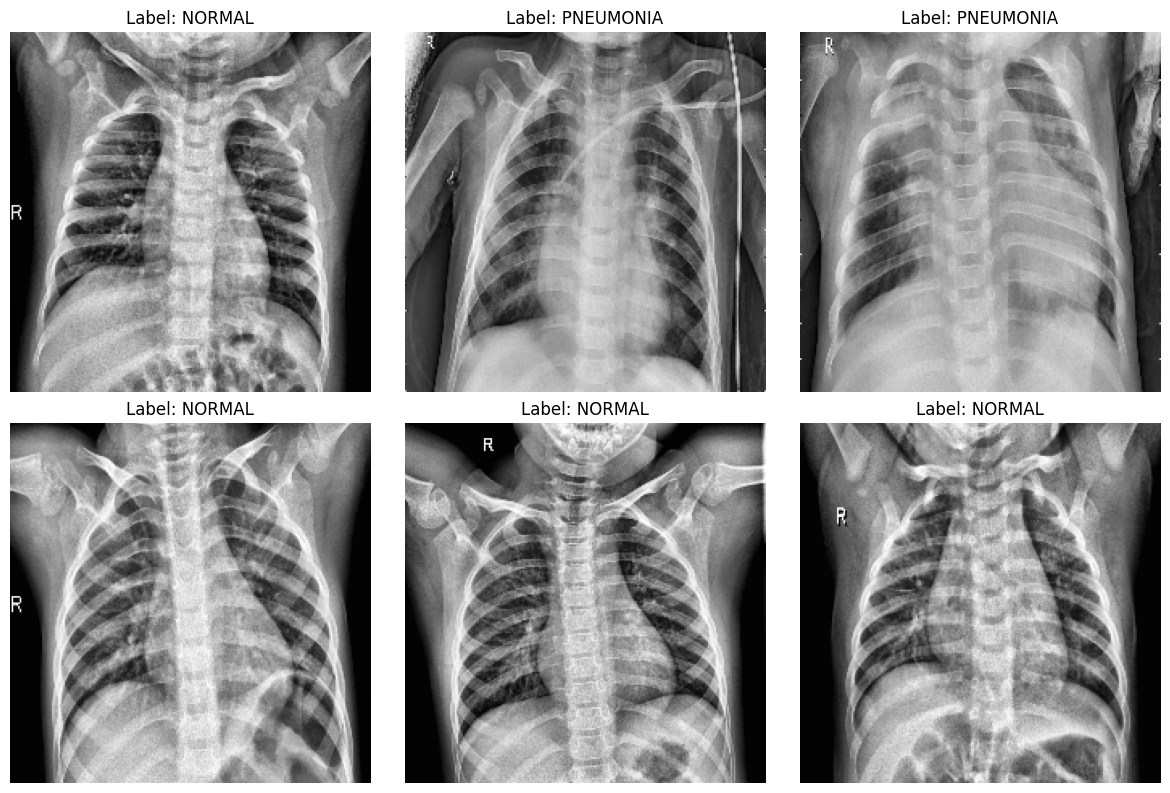

In [ ]:
# First, run the verification
quick_setup()

# If verification passes, run the full pipeline
processed_data_path = run_preprocessing_pipeline()

# Visualize some results
visualize_samples(processed_data_path)

In [ ]:
# Q-Health Scan: Comprehensive Data Visualization Suite
# Visualizations for Preprocessed Chest X-Ray Data

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from collections import Counter
import pickle
import os
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

class QHealthVisualizer:
    def __init__(self, processed_data_path):
        """Initialize the visualizer with processed data path"""
        self.data_path = processed_data_path
        self.load_data_and_encoder()

    def load_data_and_encoder(self):
        """Load preprocessed data and label encoder"""
        try:
            # Load data splits
            self.train_images, self.train_labels = self._load_split('train')
            self.val_images, self.val_labels = self._load_split('val')
            self.test_images, self.test_labels = self._load_split('test')

            # Load label encoder
            with open(os.path.join(self.data_path, 'label_encoder.pkl'), 'rb') as f:
                self.label_encoder = pickle.load(f)

            print("✓ Data and encoder loaded successfully")

        except Exception as e:
            print(f"❌ Error loading data: {e}")

    def _load_split(self, split_name):
        """Helper function to load a data split"""
        split_path = os.path.join(self.data_path, split_name)
        images = np.load(os.path.join(split_path, 'images.npy'))
        labels = np.load(os.path.join(split_path, 'labels.npy'))
        return images, labels

    def plot_dataset_distribution(self):
        """Plot the distribution of classes across train/val/test splits"""
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        # Prepare data
        splits = ['train', 'val', 'test']
        data_splits = [
            (self.train_labels, 'Training Set'),
            (self.val_labels, 'Validation Set'),
            (self.test_labels, 'Test Set')
        ]

        # Combined distribution
        all_labels = np.concatenate([self.train_labels, self.val_labels, self.test_labels])

        # Plot individual splits
        for i, (labels, title) in enumerate(data_splits):
            label_names = self.label_encoder.inverse_transform(labels)
            label_counts = Counter(label_names)

            # Create pie chart
            axes[i].pie(label_counts.values(), labels=label_counts.keys(),
                       autopct='%1.1f%%', startangle=90)
            axes[i].set_title(f'{title}\n({len(labels)} images)')

        # Overall distribution
        all_label_names = self.label_encoder.inverse_transform(all_labels)
        all_counts = Counter(all_label_names)
        colors = plt.cm.Set3(np.linspace(0, 1, len(all_counts)))

        bars = axes[3].bar(all_counts.keys(), all_counts.values(), color=colors)
        axes[3].set_title(f'Overall Distribution\n({len(all_labels)} images)')
        axes[3].set_ylabel('Number of Images')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[3].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        return all_counts

    def plot_sample_images(self, num_samples=12, split='train'):
        """Plot sample images from each class"""
        if split == 'train':
            images, labels = self.train_images, self.train_labels
        elif split == 'val':
            images, labels = self.val_images, self.val_labels
        else:
            images, labels = self.test_images, self.test_labels

        # Get unique classes
        unique_classes = np.unique(labels)
        samples_per_class = num_samples // len(unique_classes)

        fig, axes = plt.subplots(len(unique_classes), samples_per_class,
                                figsize=(samples_per_class * 3, len(unique_classes) * 3))

        if len(unique_classes) == 1:
            axes = axes.reshape(1, -1)

        for class_idx, class_label in enumerate(unique_classes):
            # Get indices for this class
            class_indices = np.where(labels == class_label)[0]
            selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)

            class_name = self.label_encoder.inverse_transform([class_label])[0]

            for sample_idx, img_idx in enumerate(selected_indices):
                img = images[img_idx]

                # Display image
                axes[class_idx, sample_idx].imshow(img, cmap='gray' if len(img.shape)==2 else None)
                axes[class_idx, sample_idx].set_title(f'{class_name}')
                axes[class_idx, sample_idx].axis('off')

        plt.suptitle(f'Sample Images from {split.title()} Set', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_image_statistics(self):
        """Plot statistical analysis of image properties"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Combine all images for analysis
        all_images = np.concatenate([self.train_images, self.val_images, self.test_images])
        all_labels = np.concatenate([self.train_labels, self.val_labels, self.test_labels])

        # Convert labels to names
        label_names = self.label_encoder.inverse_transform(all_labels)

        # Calculate statistics for each image
        mean_intensities = []
        std_intensities = []
        contrast_values = []
        brightness_values = []

        for img in all_images:
            if len(img.shape) == 3:
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            else:
                img_gray = img

            mean_intensities.append(np.mean(img_gray))
            std_intensities.append(np.std(img_gray))
            contrast_values.append(np.std(img_gray) / np.mean(img_gray) if np.mean(img_gray) > 0 else 0)
            brightness_values.append(np.percentile(img_gray, 75) - np.percentile(img_gray, 25))

        # Create DataFrame for easier plotting
        df = pd.DataFrame({
            'mean_intensity': mean_intensities,
            'std_intensity': std_intensities,
            'contrast': contrast_values,
            'brightness_range': brightness_values,
            'class': label_names
        })

        # Plot distributions
        metrics = ['mean_intensity', 'std_intensity', 'contrast', 'brightness_range']
        titles = ['Mean Intensity', 'Standard Deviation', 'Contrast Ratio', 'Brightness Range']

        for i, (metric, title) in enumerate(zip(metrics[:4], titles)):
            row, col = i // 3, i % 3

            # Box plot
            sns.boxplot(data=df, x='class', y=metric, ax=axes[row, col])
            axes[row, col].set_title(f'{title} by Class')
            axes[row, col].tick_params(axis='x', rotation=45)

        # Correlation heatmap
        correlation_data = df[metrics].corr()
        sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
        axes[1, 1].set_title('Feature Correlation Matrix')

        # Statistical comparison
        axes[1, 2].axis('off')

        # Perform statistical tests
        normal_data = df[df['class'] == 'NORMAL']
        pneumonia_data = df[df['class'] == 'PNEUMONIA']

        stats_text = "Statistical Comparison (t-test p-values):\n\n"
        for metric in metrics:
            t_stat, p_value = stats.ttest_ind(normal_data[metric], pneumonia_data[metric])
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
            stats_text += f"{metric}: p={p_value:.4f} {significance}\n"

        axes[1, 2].text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center')
        axes[1, 2].set_title('Statistical Significance')

        plt.tight_layout()
        plt.show()

        return df

    def plot_preprocessing_comparison(self, original_path=None, num_samples=6):
        """Compare original vs preprocessed images"""
        if original_path is None:
            print("Original data path not provided. Showing preprocessed images only.")
            self.plot_sample_images(num_samples)
            return

        fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))

        # Sample some images
        sample_indices = np.random.choice(len(self.train_images), num_samples, replace=False)

        for i, idx in enumerate(sample_indices):
            # Preprocessed image
            preprocessed_img = self.train_images[idx]
            label = self.label_encoder.inverse_transform([self.train_labels[idx]])[0]

            # Display preprocessed
            axes[1, i].imshow(preprocessed_img, cmap='gray' if len(preprocessed_img.shape)==2 else None)
            axes[1, i].set_title(f'Preprocessed\n{label}')
            axes[1, i].axis('off')

            # Placeholder for original (would need original data path)
            axes[0, i].text(0.5, 0.5, 'Original\nImage\nN/A', ha='center', va='center', transform=axes[0, i].transAxes)
            axes[0, i].set_title(f'Original\n{label}')
            axes[0, i].axis('off')

        plt.suptitle('Preprocessing Comparison', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_dimensionality_reduction(self, method='tsne', sample_size=1000):
        """Plot t-SNE or PCA visualization of the data"""
        # Sample data for visualization (to avoid memory issues)
        all_images = np.concatenate([self.train_images, self.val_images, self.test_images])
        all_labels = np.concatenate([self.train_labels, self.val_labels, self.test_labels])

        if len(all_images) > sample_size:
            indices = np.random.choice(len(all_images), sample_size, replace=False)
            all_images = all_images[indices]
            all_labels = all_labels[indices]

        # Flatten images for dimensionality reduction
        flattened = all_images.reshape(len(all_images), -1)

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # PCA
        print("Computing PCA...")
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(flattened)

        label_names = self.label_encoder.inverse_transform(all_labels)

        # Plot PCA
        for class_name in np.unique(label_names):
            mask = label_names == class_name
            axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1],
                          label=class_name, alpha=0.6, s=20)

        axes[0].set_title(f'PCA Visualization\nExplained Variance: {sum(pca.explained_variance_ratio_):.2f}')
        axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
        axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # t-SNE (if requested)
        if method.lower() == 'tsne':
            print("Computing t-SNE (this may take a while)...")
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_images)//4))
            tsne_result = tsne.fit_transform(flattened)

            for class_name in np.unique(label_names):
                mask = label_names == class_name
                axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                              label=class_name, alpha=0.6, s=20)

            axes[1].set_title('t-SNE Visualization')
            axes[1].set_xlabel('t-SNE 1')
            axes[1].set_ylabel('t-SNE 2')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        else:
            # Show explained variance plot
            pca_full = PCA()
            pca_full.fit(flattened[:500])  # Sample for speed
            cumsum = np.cumsum(pca_full.explained_variance_ratio_)

            axes[1].plot(range(1, min(51, len(cumsum)+1)), cumsum[:50], 'bo-', linewidth=2)
            axes[1].set_xlabel('Number of Components')
            axes[1].set_ylabel('Cumulative Explained Variance')
            axes[1].set_title('PCA Explained Variance')
            axes[1].grid(True, alpha=0.3)
            axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
            axes[1].legend()

        plt.tight_layout()
        plt.show()

    def plot_quantum_features_analysis(self):
        """Analyze quantum-ready features if available"""
        quantum_file = os.path.join(self.data_path, 'quantum_features_amplitude.npy')

        if not os.path.exists(quantum_file):
            print("❌ Quantum features not found. Run preprocessing with quantum encoding first.")
            return

        print("📊 Analyzing Quantum Features...")
        quantum_features = np.load(quantum_file)

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Feature distribution
        axes[0, 0].hist(quantum_features.flatten(), bins=50, alpha=0.7, density=True)
        axes[0, 0].set_title('Quantum Feature Value Distribution')
        axes[0, 0].set_xlabel('Feature Value')
        axes[0, 0].set_ylabel('Density')
        axes[0, 0].grid(True, alpha=0.3)

        # Feature magnitudes
        feature_magnitudes = np.linalg.norm(quantum_features, axis=1)
        axes[0, 1].hist(feature_magnitudes, bins=30, alpha=0.7)
        axes[0, 1].set_title('Quantum Feature Vector Magnitudes')
        axes[0, 1].set_xlabel('L2 Norm')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3)

        # Sample quantum features visualization
        sample_indices = np.random.choice(len(quantum_features), 5, replace=False)
        for i, idx in enumerate(sample_indices[:3]):
            axes[1, 0].plot(quantum_features[idx][:100], alpha=0.7, label=f'Sample {i+1}')

        axes[1, 0].set_title('Sample Quantum Feature Vectors (first 100 features)')
        axes[1, 0].set_xlabel('Feature Index')
        axes[1, 0].set_ylabel('Feature Value')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Quantum encoding validation
        encoding_stats = {
            'Min Value': np.min(quantum_features),
            'Max Value': np.max(quantum_features),
            'Mean': np.mean(quantum_features),
            'Std Dev': np.std(quantum_features),
            'Vector Norms (mean)': np.mean(feature_magnitudes),
            'Vector Norms (std)': np.std(feature_magnitudes)
        }

        axes[1, 1].axis('off')
        stats_text = "Quantum Encoding Statistics:\n\n"
        for key, value in encoding_stats.items():
            stats_text += f"{key}: {value:.6f}\n"

        axes[1, 1].text(0.1, 0.7, stats_text, fontsize=11, verticalalignment='top')
        axes[1, 1].set_title('Encoding Validation')

        plt.tight_layout()
        plt.show()

    def create_interactive_dashboard(self):
        """Create an interactive dashboard using Plotly"""
        # Prepare data
        all_images = np.concatenate([self.train_images, self.val_images, self.test_images])
        all_labels = np.concatenate([self.train_labels, self.val_labels, self.test_labels])
        splits = ['train'] * len(self.train_labels) + ['val'] * len(self.val_labels) + ['test'] * len(self.test_labels)

        label_names = self.label_encoder.inverse_transform(all_labels)

        # Calculate image statistics
        stats_data = []
        for i, img in enumerate(all_images[:500]):  # Sample for performance
            if len(img.shape) == 3:
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            else:
                img_gray = img

            stats_data.append({
                'mean_intensity': np.mean(img_gray),
                'std_intensity': np.std(img_gray),
                'class': label_names[i],
                'split': splits[i],
                'image_index': i
            })

        df = pd.DataFrame(stats_data)

        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Class Distribution', 'Intensity Distribution',
                          'Split Distribution', 'Intensity vs Std Dev'),
            specs=[[{"type": "pie"}, {"type": "histogram"}],
                   [{"type": "pie"}, {"type": "scatter"}]]
        )

        # Class distribution pie chart
        class_counts = df['class'].value_counts()
        fig.add_trace(go.Pie(labels=class_counts.index, values=class_counts.values,
                           name="Classes"), row=1, col=1)

        # Intensity histogram
        for class_name in df['class'].unique():
            class_data = df[df['class'] == class_name]
            fig.add_trace(go.Histogram(x=class_data['mean_intensity'],
                                     name=f'{class_name} Intensity',
                                     opacity=0.7), row=1, col=2)

        # Split distribution
        split_counts = df['split'].value_counts()
        fig.add_trace(go.Pie(labels=split_counts.index, values=split_counts.values,
                           name="Splits"), row=2, col=1)

        # Scatter plot
        for class_name in df['class'].unique():
            class_data = df[df['class'] == class_name]
            fig.add_trace(go.Scatter(x=class_data['mean_intensity'],
                                   y=class_data['std_intensity'],
                                   mode='markers',
                                   name=f'{class_name}',
                                   opacity=0.6), row=2, col=2)

        fig.update_layout(height=800, showlegend=True,
                         title_text="Q-Health Scan: Interactive Data Dashboard")

        return fig

    def generate_comprehensive_report(self):
        """Generate a comprehensive visualization report"""
        print("🎯 Generating Comprehensive Q-Health Scan Data Report")
        print("=" * 60)

        # 1. Dataset Distribution
        print("\n1. 📊 Dataset Distribution Analysis")
        dist_data = self.plot_dataset_distribution()

        # 2. Sample Images
        print("\n2. 🖼️ Sample Images Visualization")
        self.plot_sample_images(num_samples=12)

        # 3. Statistical Analysis
        print("\n3. 📈 Statistical Analysis")
        stats_df = self.plot_image_statistics()

        # 4. Dimensionality Reduction
        print("\n4. 🔍 Dimensionality Reduction Analysis")
        self.plot_dimensionality_reduction(method='tsne', sample_size=800)

        # 5. Quantum Features (if available)
        print("\n5. ⚛️ Quantum Features Analysis")
        self.plot_quantum_features_analysis()

        # 6. Summary Statistics
        print("\n6. 📋 Summary Report")
        total_images = len(self.train_images) + len(self.val_images) + len(self.test_images)

        summary = f"""
        📊 Q-HEALTH SCAN DATA SUMMARY
        ================================
        Total Images: {total_images:,}
        Training Set: {len(self.train_images):,} images
        Validation Set: {len(self.val_images):,} images
        Test Set: {len(self.test_images):,} images

        Classes: {list(self.label_encoder.classes_)}
        Image Shape: {self.train_images[0].shape}

        Statistical Insights:
        - Mean pixel intensity range: {stats_df['mean_intensity'].min():.3f} - {stats_df['mean_intensity'].max():.3f}
        - Contrast variation: {stats_df['contrast'].std():.3f}
        - Data quality: Preprocessed and normalized ✓

        Ready for Quantum ML: {'✓' if os.path.exists(os.path.join(self.data_path, 'quantum_features_amplitude.npy')) else '❌'}
        """

        print(summary)
        return summary

# Usage Examples and Main Functions
def run_complete_visualization_suite(processed_data_path):
    """Run the complete visualization suite"""
    print("🎨 Starting Q-Health Scan Visualization Suite")
    print("=" * 60)

    # Initialize visualizer
    viz = QHealthVisualizer(processed_data_path)

    # Generate comprehensive report
    summary = viz.generate_comprehensive_report()

    # Create interactive dashboard (if plotly is available)
    try:
        interactive_fig = viz.create_interactive_dashboard()
        print("\n7. 🌟 Interactive Dashboard Created (use interactive_fig.show())")
        return viz, summary, interactive_fig
    except Exception as e:
        print(f"Interactive dashboard creation failed: {e}")
        return viz, summary, None

# Quick visualization function
def quick_viz(processed_data_path, viz_type='all'):
    """Quick visualization function for specific analysis"""
    viz = QHealthVisualizer(processed_data_path)

    if viz_type == 'distribution' or viz_type == 'all':
        viz.plot_dataset_distribution()

    if viz_type == 'samples' or viz_type == 'all':
        viz.plot_sample_images()

    if viz_type == 'stats' or viz_type == 'all':
        viz.plot_image_statistics()

    if viz_type == 'quantum' or viz_type == 'all':
        viz.plot_quantum_features_analysis()

    return viz

# Example usage:
# processed_data_path = '/content/processed_data'  # Your processed data path
# viz, summary, interactive_fig = run_complete_visualization_suite(processed_data_path)
#
# # For specific visualizations:
# quick_viz(processed_data_path, viz_type='distribution')

In [ ]:
# Simple and Effective Data Visualizations for Q-Health Scan
# Using basic Python libraries that work reliably in Google Colab

import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter
import pickle

def load_preprocessed_data(data_path):
    """Load preprocessed data splits"""
    print("Loading preprocessed data...")

    # Load training data
    train_images = np.load(os.path.join(data_path, 'train', 'images.npy'))
    train_labels = np.load(os.path.join(data_path, 'train', 'labels.npy'))

    # Load validation data
    val_images = np.load(os.path.join(data_path, 'val', 'images.npy'))
    val_labels = np.load(os.path.join(data_path, 'val', 'labels.npy'))

    # Load test data
    test_images = np.load(os.path.join(data_path, 'test', 'images.npy'))
    test_labels = np.load(os.path.join(data_path, 'test', 'labels.npy'))

    # Load label encoder
    with open(os.path.join(data_path, 'label_encoder.pkl'), 'rb') as f:
        label_encoder = pickle.load(f)

    print(f"✓ Loaded {len(train_images)} training images")
    print(f"✓ Loaded {len(val_images)} validation images")
    print(f"✓ Loaded {len(test_images)} test images")
    print(f"✓ Image shape: {train_images[0].shape}")
    print(f"✓ Classes: {label_encoder.classes_}")

    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels), label_encoder

def plot_data_distribution(train_labels, val_labels, test_labels, label_encoder):
    """Plot the distribution of classes across splits"""
    print("\n1. Plotting data distribution...")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Training distribution
    train_class_names = label_encoder.inverse_transform(train_labels)
    train_counts = Counter(train_class_names)

    axes[0].bar(train_counts.keys(), train_counts.values(), color=['lightblue', 'lightcoral'])
    axes[0].set_title(f'Training Set\n({len(train_labels)} images)')
    axes[0].set_ylabel('Number of Images')

    # Add count labels on bars
    for i, (k, v) in enumerate(train_counts.items()):
        axes[0].text(i, v + 10, str(v), ha='center', va='bottom')

    # Validation distribution
    val_class_names = label_encoder.inverse_transform(val_labels)
    val_counts = Counter(val_class_names)

    axes[1].bar(val_counts.keys(), val_counts.values(), color=['lightblue', 'lightcoral'])
    axes[1].set_title(f'Validation Set\n({len(val_labels)} images)')
    axes[1].set_ylabel('Number of Images')

    for i, (k, v) in enumerate(val_counts.items()):
        axes[1].text(i, v + 1, str(v), ha='center', va='bottom')

    # Test distribution
    test_class_names = label_encoder.inverse_transform(test_labels)
    test_counts = Counter(test_class_names)

    axes[2].bar(test_counts.keys(), test_counts.values(), color=['lightblue', 'lightcoral'])
    axes[2].set_title(f'Test Set\n({len(test_labels)} images)')
    axes[2].set_ylabel('Number of Images')

    for i, (k, v) in enumerate(test_counts.items()):
        axes[2].text(i, v + 1, str(v), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Training: {dict(train_counts)}")
    print(f"Validation: {dict(val_counts)}")
    print(f"Test: {dict(test_counts)}")

def plot_sample_images(images, labels, label_encoder, split_name='Train', num_samples=12):
    """Plot sample images from each class"""
    print(f"\n2. Plotting sample {split_name.lower()} images...")

    # Get unique classes
    unique_labels = np.unique(labels)
    samples_per_class = num_samples // len(unique_labels)

    fig, axes = plt.subplots(len(unique_labels), samples_per_class, figsize=(12, 6))

    if len(unique_labels) == 1:
        axes = axes.reshape(1, -1)

    for class_idx, class_label in enumerate(unique_labels):
        # Find indices for this class
        class_indices = np.where(labels == class_label)[0]

        # Randomly select samples
        selected_indices = np.random.choice(class_indices,
                                           min(samples_per_class, len(class_indices)),
                                           replace=False)

        class_name = label_encoder.inverse_transform([class_label])[0]

        for sample_idx in range(samples_per_class):
            if sample_idx < len(selected_indices):
                img = images[selected_indices[sample_idx]]

                # Handle different image formats
                if len(img.shape) == 3:
                    # RGB image
                    axes[class_idx, sample_idx].imshow(img)
                else:
                    # Grayscale image
                    axes[class_idx, sample_idx].imshow(img, cmap='gray')

                axes[class_idx, sample_idx].set_title(f'{class_name}', fontsize=10)
            else:
                axes[class_idx, sample_idx].axis('off')

            axes[class_idx, sample_idx].axis('off')

    plt.suptitle(f'Sample {split_name} Images', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_image_properties(images, labels, label_encoder):
    """Analyze and plot basic image properties"""
    print("\n3. Analyzing image properties...")

    # Calculate properties for each image
    mean_intensities = []
    std_intensities = []
    image_labels = []

    print("Computing image statistics...")
    for i, img in enumerate(images[:1000]):  # Sample first 1000 for speed
        if len(img.shape) == 3:
            # Convert to grayscale for analysis
            gray_img = np.mean(img, axis=2)
        else:
            gray_img = img

        mean_intensities.append(np.mean(gray_img))
        std_intensities.append(np.std(gray_img))
        image_labels.append(labels[i])

    # Convert labels to names
    label_names = label_encoder.inverse_transform(image_labels)

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Mean intensity distribution by class
    normal_means = [mean_intensities[i] for i, label in enumerate(label_names) if label == 'NORMAL']
    pneumonia_means = [mean_intensities[i] for i, label in enumerate(label_names) if label == 'PNEUMONIA']

    axes[0, 0].hist(normal_means, alpha=0.7, label='NORMAL', bins=30, color='lightblue')
    axes[0, 0].hist(pneumonia_means, alpha=0.7, label='PNEUMONIA', bins=30, color='lightcoral')
    axes[0, 0].set_xlabel('Mean Pixel Intensity')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Mean Intensity Distribution by Class')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Standard deviation distribution by class
    normal_stds = [std_intensities[i] for i, label in enumerate(label_names) if label == 'NORMAL']
    pneumonia_stds = [std_intensities[i] for i, label in enumerate(label_names) if label == 'PNEUMONIA']

    axes[0, 1].hist(normal_stds, alpha=0.7, label='NORMAL', bins=30, color='lightblue')
    axes[0, 1].hist(pneumonia_stds, alpha=0.7, label='PNEUMONIA', bins=30, color='lightcoral')
    axes[0, 1].set_xlabel('Standard Deviation')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Intensity Variation by Class')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Scatter plot: Mean vs Std
    normal_indices = [i for i, label in enumerate(label_names) if label == 'NORMAL']
    pneumonia_indices = [i for i, label in enumerate(label_names) if label == 'PNEUMONIA']

    axes[1, 0].scatter([mean_intensities[i] for i in normal_indices],
                      [std_intensities[i] for i in normal_indices],
                      alpha=0.6, label='NORMAL', color='blue', s=20)
    axes[1, 0].scatter([mean_intensities[i] for i in pneumonia_indices],
                      [std_intensities[i] for i in pneumonia_indices],
                      alpha=0.6, label='PNEUMONIA', color='red', s=20)
    axes[1, 0].set_xlabel('Mean Intensity')
    axes[1, 0].set_ylabel('Standard Deviation')
    axes[1, 0].set_title('Mean vs Standard Deviation')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Box plot comparison
    data_to_plot = [normal_means, pneumonia_means]
    box_plot = axes[1, 1].boxplot(data_to_plot, labels=['NORMAL', 'PNEUMONIA'], patch_artist=True)

    # Color the boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    axes[1, 1].set_ylabel('Mean Intensity')
    axes[1, 1].set_title('Mean Intensity Comparison')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nStatistics Summary:")
    print(f"NORMAL images:")
    print(f"  Mean intensity: {np.mean(normal_means):.3f} ± {np.std(normal_means):.3f}")
    print(f"  Std deviation: {np.mean(normal_stds):.3f} ± {np.std(normal_stds):.3f}")
    print(f"PNEUMONIA images:")
    print(f"  Mean intensity: {np.mean(pneumonia_means):.3f} ± {np.std(pneumonia_means):.3f}")
    print(f"  Std deviation: {np.mean(pneumonia_stds):.3f} ± {np.std(pneumonia_stds):.3f}")

def plot_pixel_intensity_patterns(images, labels, label_encoder):
    """Plot pixel intensity patterns across different regions of X-rays"""
    print("\n4. Analyzing pixel intensity patterns...")

    # Sample a few images from each class
    normal_indices = np.where(label_encoder.inverse_transform(labels) == 'NORMAL')[0][:5]
    pneumonia_indices = np.where(label_encoder.inverse_transform(labels) == 'PNEUMONIA')[0][:5]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    # Plot normal X-rays
    for i, idx in enumerate(normal_indices):
        img = images[idx]
        if len(img.shape) == 3:
            img = np.mean(img, axis=2)  # Convert to grayscale

        im = axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'NORMAL {i+1}')
        axes[0, i].axis('off')
        plt.colorbar(im, ax=axes[0, i])

    # Plot pneumonia X-rays
    for i, idx in enumerate(pneumonia_indices):
        img = images[idx]
        if len(img.shape) == 3:
            img = np.mean(img, axis=2)  # Convert to grayscale

        im = axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'PNEUMONIA {i+1}')
        axes[1, i].axis('off')
        plt.colorbar(im, ax=axes[1, i])

    plt.tight_layout()
    plt.show()

def plot_image_size_analysis(images):
    """Analyze image dimensions and sizes"""
    print("\n5. Analyzing image dimensions...")

    heights = []
    widths = []

    for img in images[:100]:  # Sample first 100 images
        heights.append(img.shape[0])
        widths.append(img.shape[1])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Height distribution
    axes[0].hist(heights, bins=20, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Height (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Image Height Distribution')
    axes[0].grid(True, alpha=0.3)

    # Width distribution
    axes[1].hist(widths, bins=20, color='lightgreen', edgecolor='black')
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Image Width Distribution')
    axes[1].grid(True, alpha=0.3)

    # Height vs Width scatter
    axes[2].scatter(widths, heights, alpha=0.6, color='orange')
    axes[2].set_xlabel('Width (pixels)')
    axes[2].set_ylabel('Height (pixels)')
    axes[2].set_title('Width vs Height')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Image dimensions:")
    print(f"  Height range: {min(heights)} - {max(heights)} pixels")
    print(f"  Width range: {min(widths)} - {max(widths)} pixels")
    print(f"  Most common size: {heights[0]} x {widths[0]} pixels")

def create_summary_visualization(train_data, val_data, test_data, label_encoder):
    """Create a comprehensive summary visualization"""
    print("\n6. Creating summary visualization...")

    train_images, train_labels = train_data
    val_images, val_labels = val_data
    test_images, test_labels = test_data

    # Calculate overall statistics
    total_images = len(train_images) + len(val_images) + len(test_images)
    all_labels = np.concatenate([train_labels, val_labels, test_labels])
    all_class_names = label_encoder.inverse_transform(all_labels)
    overall_counts = Counter(all_class_names)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Overall class distribution
    axes[0, 0].pie(overall_counts.values(), labels=overall_counts.keys(),
                   autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    axes[0, 0].set_title(f'Overall Class Distribution\n({total_images:,} total images)')

    # 2. Split size comparison
    split_sizes = [len(train_images), len(val_images), len(test_images)]
    split_names = ['Train', 'Validation', 'Test']

    bars = axes[0, 1].bar(split_names, split_sizes, color=['green', 'orange', 'red'])
    axes[0, 1].set_ylabel('Number of Images')
    axes[0, 1].set_title('Dataset Split Sizes')

    # Add value labels on bars
    for bar, size in zip(bars, split_sizes):
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{size:,}', ha='center', va='bottom')

    # 3. Sample intensity comparison
    sample_normal = train_images[train_labels == 0][0]  # First normal image
    sample_pneumonia = train_images[train_labels == 1][0]  # First pneumonia image

    if len(sample_normal.shape) == 3:
        sample_normal = np.mean(sample_normal, axis=2)
        sample_pneumonia = np.mean(sample_pneumonia, axis=2)

    axes[1, 0].imshow(sample_normal, cmap='gray')
    axes[1, 0].set_title('Sample NORMAL X-ray')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(sample_pneumonia, cmap='gray')
    axes[1, 1].set_title('Sample PNEUMONIA X-ray')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Print final summary
    print(f"\n" + "="*50)
    print(f"Q-HEALTH SCAN DATASET SUMMARY")
    print(f"="*50)
    print(f"Total Images: {total_images:,}")
    print(f"Training: {len(train_images):,} images")
    print(f"Validation: {len(val_images):,} images")
    print(f"Test: {len(test_images):,} images")
    print(f"Image Shape: {train_images[0].shape}")
    print(f"Classes: {list(label_encoder.classes_)}")
    print(f"Class Distribution: {dict(overall_counts)}")
    print(f"Data Type: {train_images.dtype}")
    print(f"Pixel Value Range: [{train_images.min():.3f}, {train_images.max():.3f}]")
    print(f"="*50)

def run_all_visualizations(processed_data_path):
    """Run all visualizations in sequence"""
    print("🎯 Q-Health Scan: Complete Data Visualization Suite")
    print("="*60)

    try:
        # Load data
        train_data, val_data, test_data, label_encoder = load_preprocessed_data(processed_data_path)

        # Run visualizations
        plot_data_distribution(train_data[1], val_data[1], test_data[1], label_encoder)
        plot_sample_images(train_data[0], train_data[1], label_encoder, 'Training')
        plot_image_properties(train_data[0], train_data[1], label_encoder)
        plot_pixel_intensity_patterns(train_data[0], train_data[1], label_encoder)
        plot_image_size_analysis(train_data[0])
        create_summary_visualization(train_data, val_data, test_data, label_encoder)

        print("\n✅ All visualizations completed successfully!")
        return train_data, val_data, test_data, label_encoder

    except FileNotFoundError as e:
        print(f"❌ Error: Could not find preprocessed data at {processed_data_path}")
        print(f"Make sure you've run the preprocessing pipeline first!")
        return None
    except Exception as e:
        print(f"❌ Error during visualization: {e}")
        return None

# Quick individual visualization functions
def quick_samples(processed_data_path, split='train', num_samples=8):
    """Quick function to show sample images"""
    try:
        if split == 'train':
            images = np.load(os.path.join(processed_data_path, 'train', 'images.npy'))
            labels = np.load(os.path.join(processed_data_path, 'train', 'labels.npy'))
        elif split == 'val':
            images = np.load(os.path.join(processed_data_path, 'val', 'images.npy'))
            labels = np.load(os.path.join(processed_data_path, 'val', 'labels.npy'))
        else:
            images = np.load(os.path.join(processed_data_path, 'test', 'images.npy'))
            labels = np.load(os.path.join(processed_data_path, 'test', 'labels.npy'))

        with open(os.path.join(processed_data_path, 'label_encoder.pkl'), 'rb') as f:
            label_encoder = pickle.load(f)

        plot_sample_images(images, labels, label_encoder, split.title(), num_samples)

    except Exception as e:
        print(f"Error: {e}")

def quick_distribution(processed_data_path):
    """Quick function to show data distribution"""
    try:
        train_labels = np.load(os.path.join(processed_data_path, 'train', 'labels.npy'))
        val_labels = np.load(os.path.join(processed_data_path, 'val', 'labels.npy'))
        test_labels = np.load(os.path.join(processed_data_path, 'test', 'labels.npy'))

        with open(os.path.join(processed_data_path, 'label_encoder.pkl'), 'rb') as f:
            label_encoder = pickle.load(f)

        plot_data_distribution(train_labels, val_labels, test_labels, label_encoder)

    except Exception as e:
        print(f"Error: {e}")

# Usage Examples:
# 1. Run all visualizations:
# run_all_visualizations('/content/processed_data')
#
# 2. Quick sample images:
# quick_samples('/content/processed_data', split='train', num_samples=12)
#
# 3. Quick distribution:
# quick_distribution('/content/processed_data')

🎯 Q-Health Scan: Complete Data Visualization Suite
Loading preprocessed data...
✓ Loaded 2235 training images
✓ Loaded 479 validation images
✓ Loaded 480 test images
✓ Image shape: (224, 224, 3)
✓ Classes: ['NORMAL' 'PNEUMONIA']

1. Plotting data distribution...


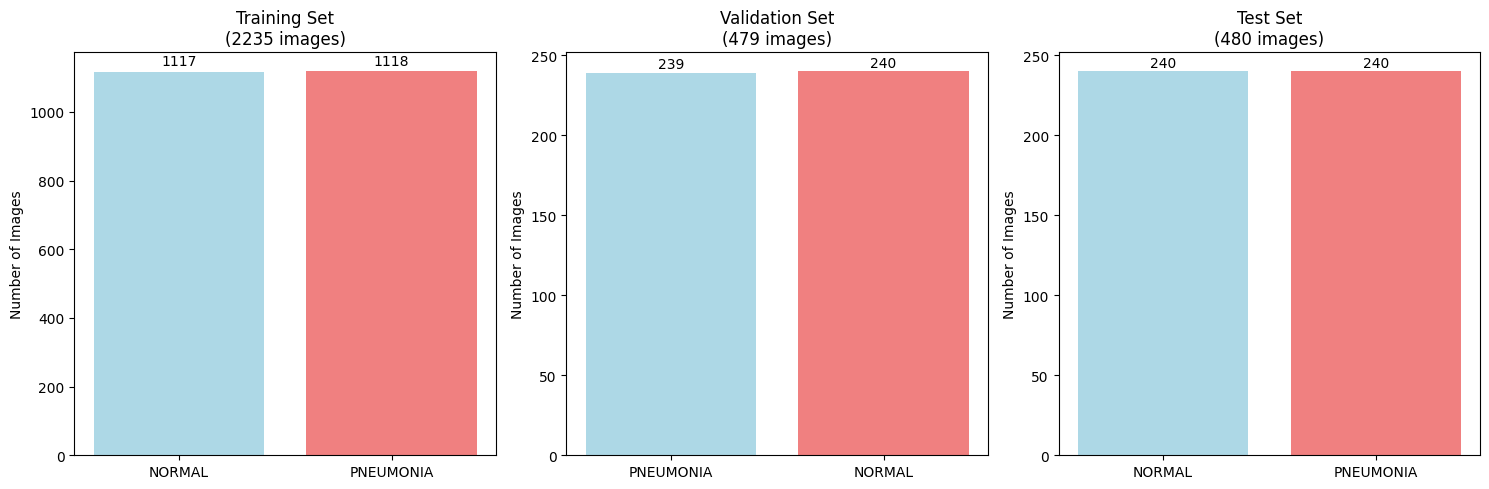

Training: {np.str_('NORMAL'): 1117, np.str_('PNEUMONIA'): 1118}
Validation: {np.str_('PNEUMONIA'): 239, np.str_('NORMAL'): 240}
Test: {np.str_('NORMAL'): 240, np.str_('PNEUMONIA'): 240}

2. Plotting sample training images...


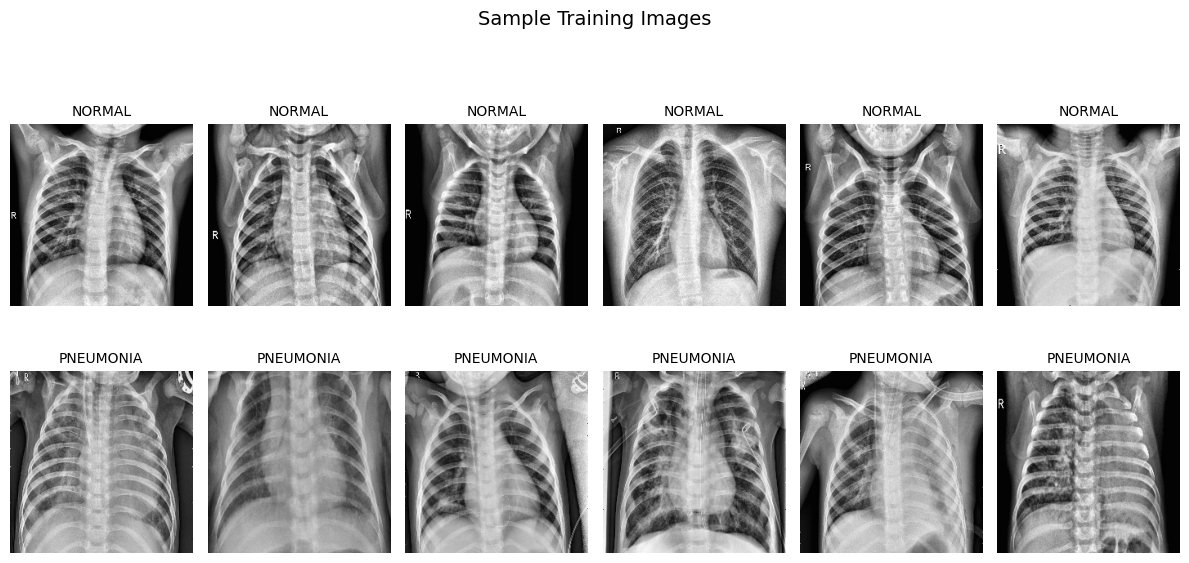


3. Analyzing image properties...
Computing image statistics...


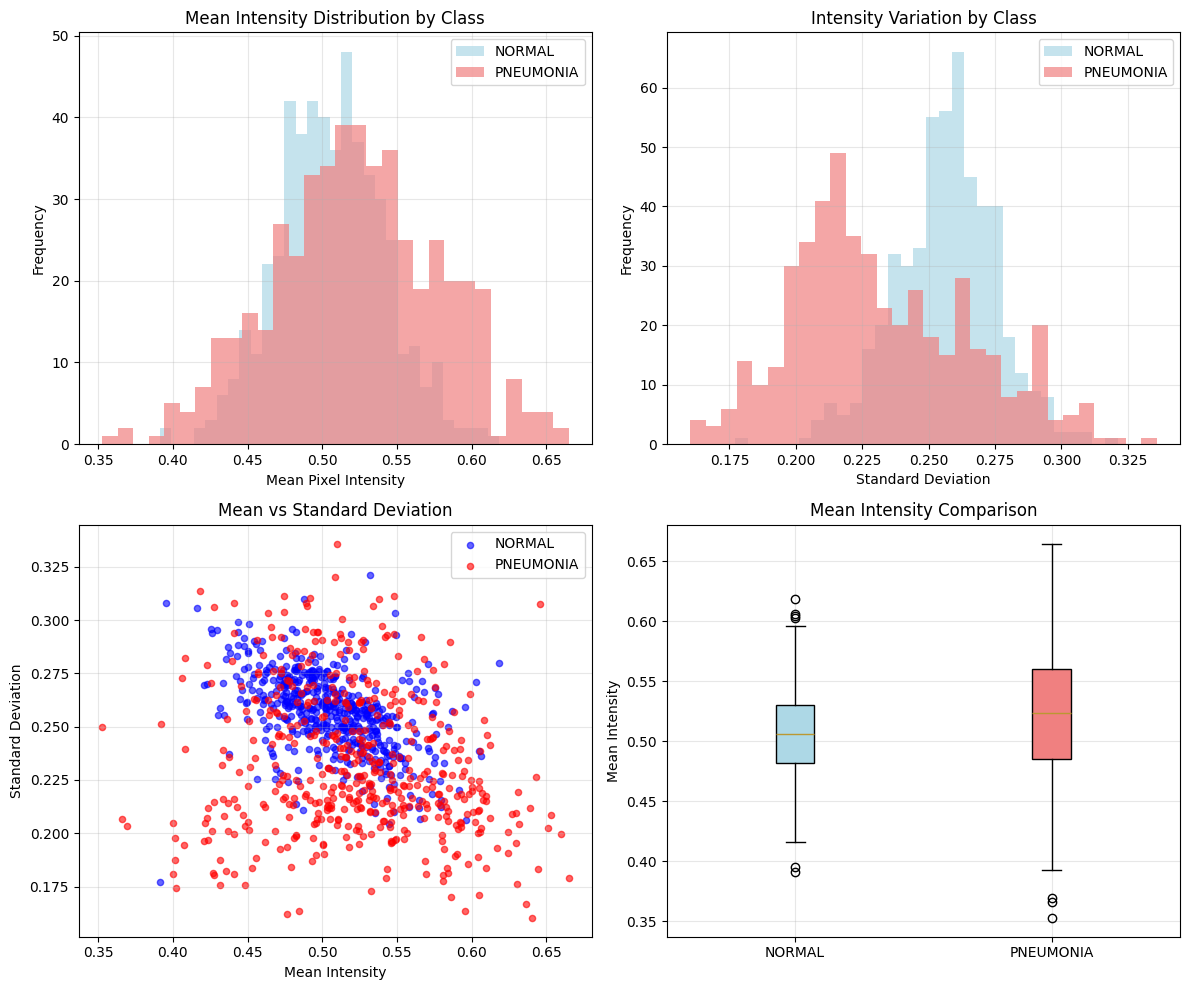


Statistics Summary:
NORMAL images:
  Mean intensity: 0.506 ± 0.036
  Std deviation: 0.257 ± 0.019
PNEUMONIA images:
  Mean intensity: 0.523 ± 0.056
  Std deviation: 0.232 ± 0.033

4. Analyzing pixel intensity patterns...


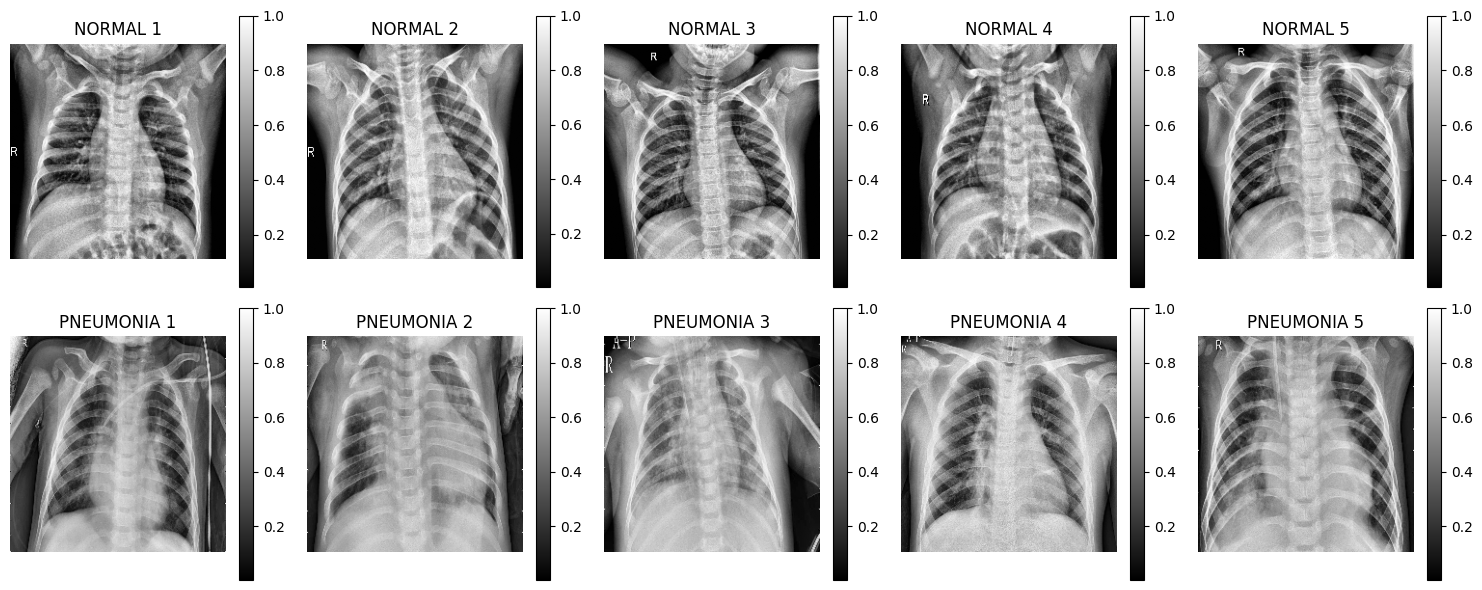


5. Analyzing image dimensions...


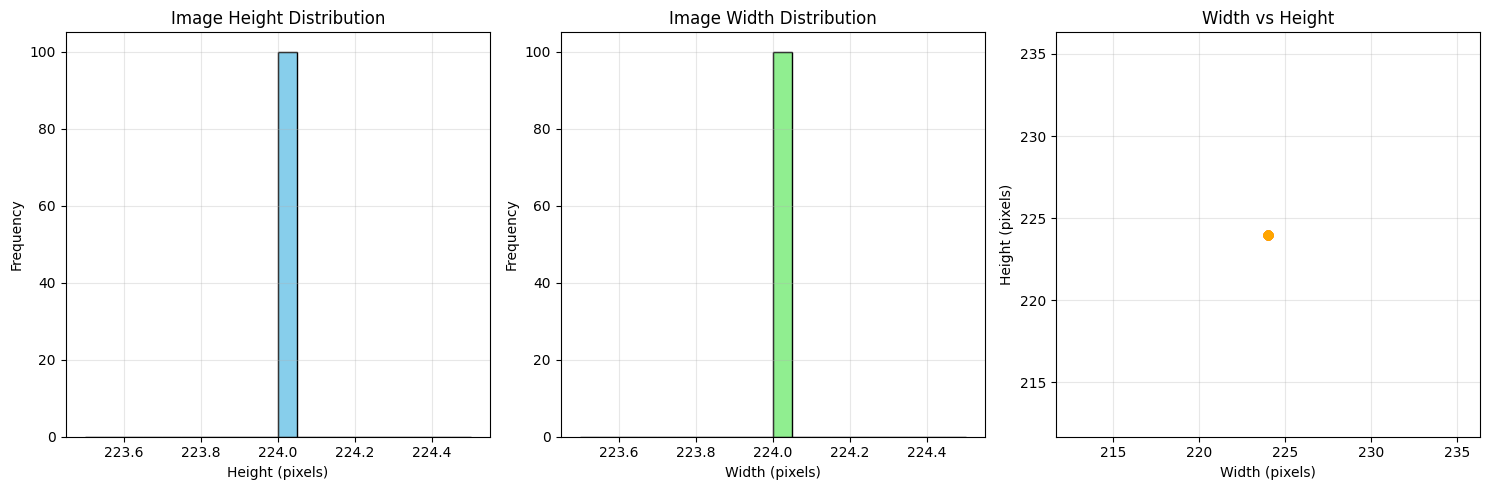

Image dimensions:
  Height range: 224 - 224 pixels
  Width range: 224 - 224 pixels
  Most common size: 224 x 224 pixels

6. Creating summary visualization...


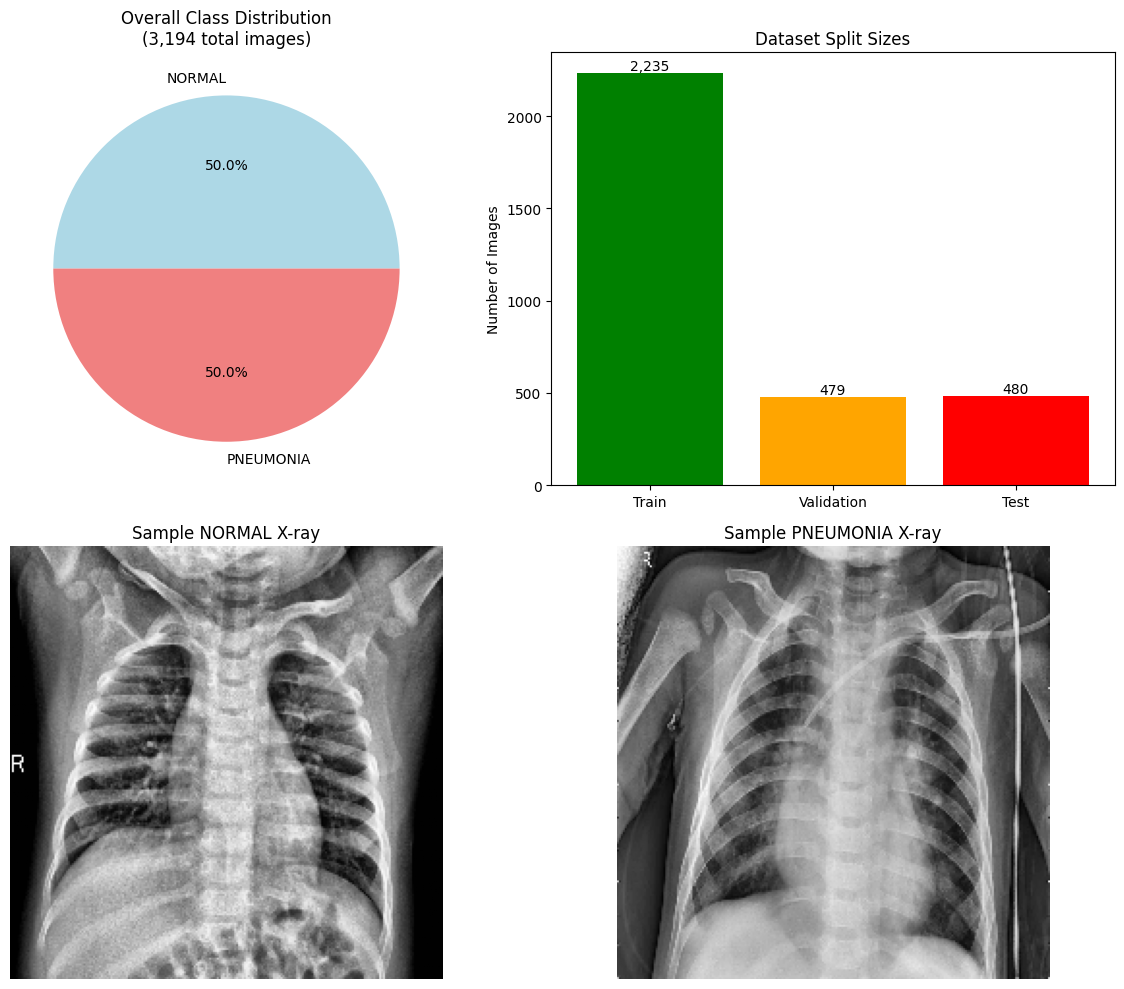


Q-HEALTH SCAN DATASET SUMMARY
Total Images: 3,194
Training: 2,235 images
Validation: 479 images
Test: 480 images
Image Shape: (224, 224, 3)
Classes: [np.str_('NORMAL'), np.str_('PNEUMONIA')]
Class Distribution: {np.str_('NORMAL'): 1597, np.str_('PNEUMONIA'): 1597}
Data Type: float32
Pixel Value Range: [0.000, 1.000]

✅ All visualizations completed successfully!


((array([[[[0.2784314 , 0.2784314 , 0.2784314 ],
           [0.28627452, 0.28627452, 0.28627452],
           [0.32156864, 0.32156864, 0.32156864],
           ...,
           [0.6313726 , 0.6313726 , 0.6313726 ],
           [0.59607846, 0.59607846, 0.59607846],
           [0.6313726 , 0.6313726 , 0.6313726 ]],
  
          [[0.28627452, 0.28627452, 0.28627452],
           [0.29411766, 0.29411766, 0.29411766],
           [0.34901962, 0.34901962, 0.34901962],
           ...,
           [0.5372549 , 0.5372549 , 0.5372549 ],
           [0.54901963, 0.54901963, 0.54901963],
           [0.49019608, 0.49019608, 0.49019608]],
  
          [[0.27058825, 0.27058825, 0.27058825],
           [0.2784314 , 0.2784314 , 0.2784314 ],
           [0.3137255 , 0.3137255 , 0.3137255 ],
           ...,
           [0.5647059 , 0.5647059 , 0.5647059 ],
           [0.5019608 , 0.5019608 , 0.5019608 ],
           [0.44313726, 0.44313726, 0.44313726]],
  
          ...,
  
          [[0.00784314, 0.00784314, 0.00

In [ ]:
run_all_visualizations('/content/processed_data')


1. Plotting data distribution...


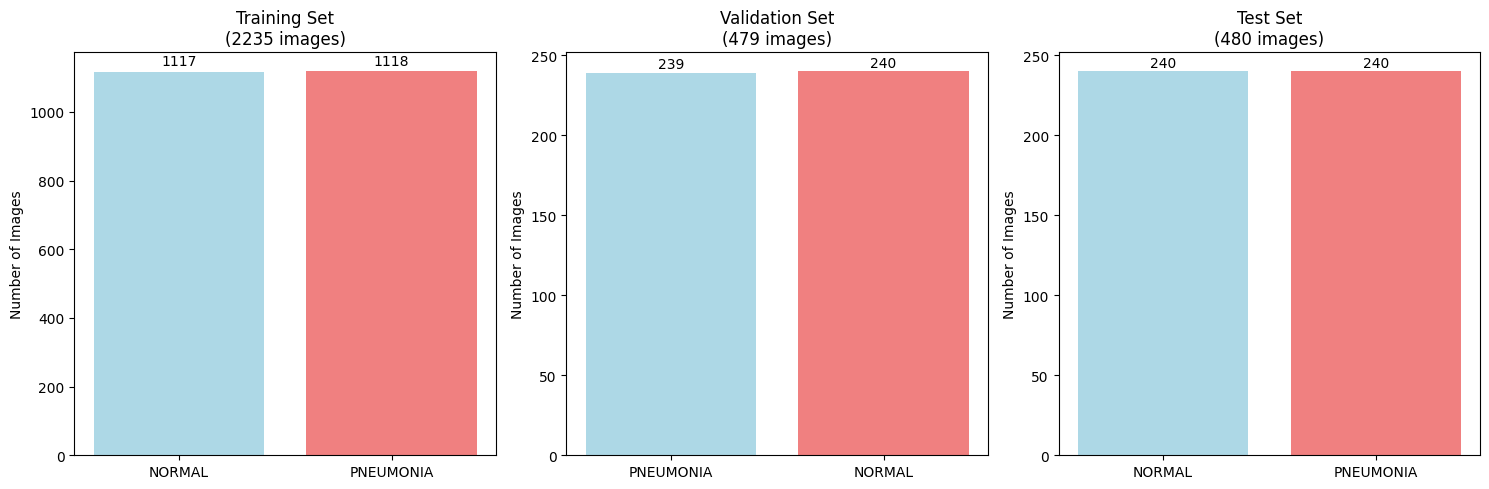

Training: {np.str_('NORMAL'): 1117, np.str_('PNEUMONIA'): 1118}
Validation: {np.str_('PNEUMONIA'): 239, np.str_('NORMAL'): 240}
Test: {np.str_('NORMAL'): 240, np.str_('PNEUMONIA'): 240}


In [ ]:
quick_distribution('/content/processed_data')